<a href="https://colab.research.google.com/github/behraj/workshops/blob/main/CalTwin_MWM4MICCAI2026(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 CalTwin — Calibrated Medical World Models
### MWM4MICCAI 2026 Workshop Implementation

**Paper:** *Calibrated, Covariate-Shift-Robust Medical World Models via Fisher-Information Regularization*

**Method components (matching paper equations):**
| Component | Paper Eq. | What it does |
|-----------|-----------|--------------|
| Latent Transition Predictor | §3.1 | GRU-based $p_\theta(s_{t+1}\mid s_t, a_t)$ |
| Diagonal Empirical FIM | Eq. (2) | $\hat{I}_i = \frac{1}{N}\sum_n \left(\frac{\partial \log p_\theta}{\partial \theta_i}\right)^2$ |
| Fisher Penalty $\mathcal{L}_{\text{shift}}$ | Eq. (3) | Cross-fragment shift regulariser |
| Confidence Misalignment Penalty (CMP) | Eq. (4) | Calibration on binary auxiliary head |
| **CalTwin Objective** | Eq. (5) | $\mathcal{L} = \text{NLL} + \lambda_1 \mathcal{L}_{\text{FIM}} + \lambda_2 \mathcal{L}_{\text{CMP}}$ |

**Dataset (default):** Real PhysioNet 2019 Sepsis Challenge — 3 chronological training fragments from Hospital System A + Hospital System B held out as the OOD test site (`USE_REAL_DATA = True` in Cell 2).  
**Fallback dataset:** synthetic AR(1) multi-site simulator, used only if `USE_REAL_DATA = False` or the PhysioNet download is unavailable — treat this as a sanity check, not a reportable result.

> 💡 **How to run:** `Runtime → Run all`. The default run downloads ~200 MB from PhysioNet (no account needed) and trains on real ICU data.

## Cell 1 · Install Dependencies

In [ ]:
# Install required packages (Colab-compatible)
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *pkgs, "-q",
         "--break-system-packages"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

_pip("torch", "numpy", "pandas", "scikit-learn",
     "matplotlib", "seaborn", "tqdm")

print("✅ All packages ready.")

✅ All packages ready.


## Cell 2 · Imports & Hyper-Parameters

In [ ]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ═══════════════════════════════════════════════════════════════════════════
# HYPER-PARAMETERS  — feel free to adjust
# ═══════════════════════════════════════════════════════════════════════════

# Data
N_TRAIN_PER_SITE = 400   # patients per training hospital site
N_TEST_PER_SITE  = 150   # patients for each test set
N_TRAIN_SITES    = 3     # number of hospital fragments (trained sequentially)
N_FEATURES       = 8     # vital-sign features per time step
T_STEPS          = 24    # trajectory length (hours)

# Model
LATENT_DIM       = 32
HIDDEN_DIM       = 64
DROPOUT          = 0.10

# Training
EPOCHS_PER_FRAG  = 40    # epochs per hospital fragment
BATCH_SIZE       = 32
LR               = 1e-3
WEIGHT_DECAY     = 1e-4

# CalTwin penalties
LAMBDA_FIM       = 0.5   # λ₁  Fisher penalty weight      (Eq. 3)
LAMBDA_CMP       = 0.3   # λ₂  CMP weight                 (Eq. 4)
FIM_EMA_ALPHA    = 0.9   # α   EMA decay for accumulated FIM

# Set True (default) to download & train on real PhysioNet 2019 Sepsis data (~200 MB).
# Set False only to fall back to the synthetic AR(1) simulator (e.g. no internet access,
# or you explicitly want the synthetic ablation from the original prototype).
USE_REAL_DATA    = True

print("✅ Hyper-parameters set.")

Device : cuda
✅ Hyper-parameters set.


## Cell 3 · Multi-Site ICU Data — Real PhysioNet 2019 (default) or Synthetic Fallback

**Primary path (`USE_REAL_DATA = True`, set in Cell 2):** downloads the PhysioNet 2019 Sepsis
Challenge and builds real multi-site fragments:

| Detail | Value |
|--------|-------|
| Source | PhysioNet 2019 Challenge — publicly downloadable, **no credentialing required** |
| URL | https://physionet.org/content/challenge-2019/1.0.0/ |
| Features | HR, O2Sat, Temp, SBP, MAP, DBP, Resp (7 vitals; EtCO2 dropped — missing for the large majority of patients) |
| Label | `SepsisLabel` (binary, max over stay) |
| Training fragments (Sites 0–2) | 3 chronological terciles of **Hospital System A** (patient-ID order ≈ enrollment order per the Challenge docs — a real temporal/practice-pattern drift *within* one hospital) |
| In-distribution test | held-out 15% tail of each Hospital-A fragment |
| OOD test (Site 3) | the *entirety* of **Hospital System B** — a different hospital, never seen in training. A vs B is a documented institutional shift (differing demographics, missingness, and sepsis prevalence — Reyna et al., *Critical Care Medicine* 2020, the official Challenge paper) |

**Fallback path** (`USE_REAL_DATA = False`, or if the PhysioNet download fails — e.g. no outbound
internet access): the original synthetic AR(1) simulator below, useful only as a quick sanity
check / ablation, **not** as a result to report to a reviewer.

Either branch defines the same `train_loaders` / `id_loader` / `ood_loader` globals, so every
cell downstream (model, training, evaluation, results table, plots) works unmodified regardless
of which data source was used.

In [ ]:
class ICUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


# ═══════════════════════════════════════════════════════════════════════════
# DATA SOURCE: real PhysioNet 2019 Sepsis Challenge by default (USE_REAL_DATA=True
# in Cell 2). Falls back to the synthetic AR(1) simulator only if USE_REAL_DATA=False
# or the PhysioNet download fails (e.g. no internet access in this environment).
# Whichever branch runs, it defines the same three globals used by every later
# cell: `train_loaders` (list of 3 fragment DataLoaders), `id_loader`, `ood_loader`.
# ═══════════════════════════════════════════════════════════════════════════

REAL_DATA_LOADED = False

if USE_REAL_DATA:
    import urllib.request, zipfile, glob

    REAL_MAX_PAT_PER_SITE = 1200   # cap per Hospital-A fragment (speed control)
    REAL_MAX_PAT_OOD      = 1200   # cap for Hospital-B OOD site
    REAL_EPOCHS_PER_FRAG  = 15     # real data is larger/noisier -> fewer epochs than synthetic

    FEAT = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]   # EtCO2 dropped: ~empty in PhysioNet 2019
    CLINICAL_FALLBACK = dict(HR=85.0, O2Sat=97.0, Temp=37.0, SBP=120.0,
                              MAP=80.0, DBP=70.0, Resp=18.0)       # used only if a whole column is NaN

    print("Downloading PhysioNet 2019 Sepsis Challenge data …")
    BASE = "https://physionet.org/files/challenge-2019/1.0.0/"
    os.makedirs("physionet2019", exist_ok=True)

    try:
        for part in ["training_setA.zip", "training_setB.zip"]:
            if not os.path.exists(part):
                print(f"  Downloading {part} …")
                urllib.request.urlretrieve(BASE + part, part)
                with zipfile.ZipFile(part, "r") as z:
                    z.extractall("physionet2019")
        print("  Download complete.\n")

        def load_psv_site(folder, max_pat=2000):
            """Parse PhysioNet .psv files into (N, T_STEPS, len(FEAT)) trajectories + binary labels."""
            files = sorted(glob.glob(os.path.join(folder, "*.psv")))[:max_pat]
            Xs, ys = [], []
            for fp in files:
                df = pd.read_csv(fp, sep="|")[FEAT + ["SepsisLabel"]]
                df = df.ffill().bfill()
                for f in FEAT:                       # guard against a feature that's 100% missing
                    df[f] = df[f].fillna(CLINICAL_FALLBACK[f])
                mat = df[FEAT].values[:T_STEPS].astype(np.float32)
                if len(mat) < 4:
                    continue
                if len(mat) < T_STEPS:                # pad by repeating last observed state
                    pad = np.repeat(mat[-1:], T_STEPS - len(mat), axis=0)
                    mat = np.vstack([mat, pad])
                mu_ = mat.mean(0, keepdims=True)
                sd_ = mat.std(0, keepdims=True) + 1e-6
                Xs.append((mat - mu_) / sd_)
                ys.append(float(df["SepsisLabel"].max() > 0))
            return np.array(Xs, np.float32), np.array(ys, np.float32)

        print("Parsing Hospital System A (training fragments) …")
        XA_all, yA_all = load_psv_site(
            "physionet2019/training_setA", max_pat=REAL_MAX_PAT_PER_SITE * N_TRAIN_SITES
        )
        print("Parsing Hospital System B (held-out OOD site) …")
        XB, yB = load_psv_site("physionet2019/training_setB", max_pat=REAL_MAX_PAT_OOD)

        # Split Hospital A into N_TRAIN_SITES chronological fragments
        # (ID order approximates enrollment order per the Challenge documentation —
        #  a real temporal/practice-pattern drift within one hospital system).
        n_per_frag = len(XA_all) // N_TRAIN_SITES
        train_loaders, _id_X, _id_y = [], [], []
        for k in range(N_TRAIN_SITES):
            lo = k * n_per_frag
            hi = (k + 1) * n_per_frag if k < N_TRAIN_SITES - 1 else len(XA_all)
            Xk, yk = XA_all[lo:hi], yA_all[lo:hi]
            split = int(0.85 * len(Xk))               # last 15% of each fragment -> ID test
            train_loaders.append(
                DataLoader(ICUDataset(Xk[:split], yk[:split]), batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=False)
            )
            _id_X.append(Xk[split:]); _id_y.append(yk[split:])
            print(f"  Site {k} (Hospital A, fragment {k+1}/{N_TRAIN_SITES}, training)  — "
                  f"patients: {split}  | sepsis prevalence: {yk[:split].mean():.1%}")

        Xid = np.concatenate(_id_X); yid = np.concatenate(_id_y)
        id_loader  = DataLoader(ICUDataset(Xid, yid), batch_size=BATCH_SIZE)
        ood_loader = DataLoader(ICUDataset(XB, yB),   batch_size=BATCH_SIZE)
        print(f"  Site 3 (Hospital B, OOD test)      — "
              f"patients: {len(XB)}  | sepsis prevalence: {yB.mean():.1%}")

        N_FEATURES      = len(FEAT)         # real data has 7 usable vitals, not 8
        EPOCHS_PER_FRAG = REAL_EPOCHS_PER_FRAG
        REAL_DATA_LOADED = True
        print(f"\n✅ Real PhysioNet 2019 dataloaders ready "
              f"(N_FEATURES={N_FEATURES}, EPOCHS_PER_FRAG={EPOCHS_PER_FRAG}).")

    except Exception as e:
        print(f"⚠️  Could not download/parse PhysioNet data ({e}).")
        print("    Falling back to the synthetic simulator below. If you're running "
              "this in a network-restricted environment, run it on Colab or a machine "
              "with outbound internet access to physionet.org to get real-data numbers.")

if not REAL_DATA_LOADED:
    # ── Synthetic AR(1) multi-site fallback (only runs if USE_REAL_DATA=False, or the
    #    PhysioNet download above failed) ───────────────────────────────────────────
    print("\nUsing SYNTHETIC multi-site ICU data "
          "(set USE_REAL_DATA=True in Cell 2, with internet access, for real PhysioNet results).\n")

    # Site-specific parameters: [HR, SBP, DBP, SpO2, Temp, RR, GCS, Lactate]
    SITE_CFG = {
        0: dict(mu   =np.array([80,  120, 80,  97.0, 37.0, 16, 14, 1.2]),
                sigma=np.array([ 8,   12,  8,   1.5,  0.3,  2, 0.5, 0.3]),
                ar=0.85, noise=1.0, thr=1.8),   # general ward

        1: dict(mu   =np.array([92,  108, 70,  95.0, 37.8, 20, 13, 2.1]),
                sigma=np.array([12,   15, 10,   2.0,  0.5,  3, 0.8, 0.5]),
                ar=0.80, noise=1.4, thr=2.0),   # high-acuity (different demographics)

        2: dict(mu   =np.array([75,  130, 85,  98.0, 36.8, 14, 15, 0.9]),
                sigma=np.array([ 6,   10,  7,   1.0,  0.2,  2, 0.3, 0.2]),
                ar=0.88, noise=0.8, thr=1.6),   # low-acuity / elderly

        3: dict(mu   =np.array([88,  115, 75,  96.0, 37.5, 18, 13, 1.7]),   # ← OOD
                sigma=np.array([10,   13,  9,   1.8,  0.4,2.5, 0.6, 0.4]),
                ar=0.82, noise=1.2, thr=1.9),
    }

    CLIP = [(40,200),(60,200),(30,130),(70,100),(35,42),(6,40),(3,15),(0.5,10)]

    def generate_trajectories(site_id, n_patients, rng):
        """Return X_norm (n, T, F) and y (n,)."""
        c  = SITE_CFG[site_id]
        mu, sigma = c["mu"], c["sigma"]

        X = np.zeros((n_patients, T_STEPS, N_FEATURES))
        X[:, 0, :] = rng.normal(mu, sigma, size=(n_patients, N_FEATURES))
        for t in range(1, T_STEPS):
            noise      = rng.normal(0, sigma * c["noise"], size=(n_patients, N_FEATURES))
            X[:, t, :] = c["ar"] * X[:, t-1, :] + (1 - c["ar"]) * mu + noise
        for f, (lo, hi) in enumerate(CLIP):
            X[:, :, f] = np.clip(X[:, :, f], lo, hi)

        X_norm = (X - mu) / (sigma * 3 + 1e-6)

        mid = T_STEPS // 2
        y   = ((X[:, mid:, 7].mean(1) > c["thr"]) &
               (X[:, mid:, 0].mean(1) > mu[0] + sigma[0]) &
               (X[:, mid:, 5].mean(1) > mu[5] + sigma[5])).astype(np.float32)

        return X_norm.astype(np.float32), y

    def build_loaders(rng):
        train_loaders = []
        for k in range(N_TRAIN_SITES):
            X, y = generate_trajectories(k, N_TRAIN_PER_SITE, rng)
            train_loaders.append(
                DataLoader(ICUDataset(X, y), batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=False))

        Xid = np.concatenate([generate_trajectories(k, N_TEST_PER_SITE//3, rng)[0]
                               for k in range(N_TRAIN_SITES)])
        yid = np.concatenate([generate_trajectories(k, N_TEST_PER_SITE//3, rng)[1]
                               for k in range(N_TRAIN_SITES)])

        Xod, yod = generate_trajectories(3, N_TEST_PER_SITE, rng)

        id_loader  = DataLoader(ICUDataset(Xid, yid), batch_size=BATCH_SIZE)
        ood_loader = DataLoader(ICUDataset(Xod, yod), batch_size=BATCH_SIZE)
        return train_loaders, id_loader, ood_loader

    print("Generating synthetic multi-site ICU trajectories …")
    rng = np.random.default_rng(SEED)
    train_loaders, id_loader, ood_loader = build_loaders(rng)

    for k in range(N_TRAIN_SITES):
        X_tmp, y_tmp = generate_trajectories(k, N_TRAIN_PER_SITE, rng)
        print(f"  Site {k} (training)  — patients: {N_TRAIN_PER_SITE}  "
              f"| sepsis prevalence: {y_tmp.mean():.1%}")
    X_ood, y_ood = generate_trajectories(3, N_TEST_PER_SITE, rng)
    print(f"  Site 3 (OOD test)   — patients: {N_TEST_PER_SITE}  "
          f"| sepsis prevalence: {y_ood.mean():.1%}")
    print("\n✅ Synthetic dataloaders ready.")


⚠️  Could not download/parse PhysioNet data (HTTP Error 404: Not Found).
    Falling back to the synthetic simulator below. If you're running this in a network-restricted environment, run it on Colab or a machine with outbound internet access to physionet.org to get real-data numbers.

Using SYNTHETIC multi-site ICU data (set USE_REAL_DATA=True in Cell 2, with internet access, for real PhysioNet results).

Generating synthetic multi-site ICU trajectories …
  Site 0 (training)  — patients: 400  | sepsis prevalence: 0.2%
  Site 1 (training)  — patients: 400  | sepsis prevalence: 4.3%
  Site 2 (training)  — patients: 400  | sepsis prevalence: 0.0%
  Site 3 (OOD test)   — patients: 150  | sepsis prevalence: 1.3%

✅ Synthetic dataloaders ready.


In [ ]:
class ICUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


# ═══════════════════════════════════════════════════════════════════════════
# DATA SOURCE: real PhysioNet 2019 Sepsis Challenge by default (USE_REAL_DATA=True
# in Cell 2). Falls back to the synthetic AR(1) simulator only if USE_REAL_DATA=False
# or the PhysioNet download fails (e.g. no internet access in this environment).
# Whichever branch runs, it defines the same three globals used by every later
# cell: `train_loaders` (list of 3 fragment DataLoaders), `id_loader`, `ood_loader`.
# ═══════════════════════════════════════════════════════════════════════════

REAL_DATA_LOADED = False

if USE_REAL_DATA:
    import glob

    REAL_MAX_PAT_PER_SITE = 1200   # cap per Hospital-A fragment (speed control)
    REAL_MAX_PAT_OOD      = 1200   # cap for Hospital-B OOD site
    REAL_EPOCHS_PER_FRAG  = 15     # real data is larger/noisier -> fewer epochs than synthetic

    FEAT = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]   # EtCO2 dropped: ~empty in PhysioNet 2019
    CLINICAL_FALLBACK = dict(HR=85.0, O2Sat=97.0, Temp=37.0, SBP=120.0,
                              MAP=80.0, DBP=70.0, Resp=18.0)       # used only if a whole column is NaN

    print("Downloading PhysioNet 2019 Sepsis Challenge data …")

    # NOTE: PhysioNet no longer serves training_setA.zip / training_setB.zip at the
    # dataset root (those URLs now 404) — the Challenge is only published as one .psv
    # file per subject under .../training/{training_setA,training_setB}/. We instead
    # pull individual files from PhysioNet's public, no-sign-required S3 mirror
    # (s3://physionet-open/challenge-2019/1.0.0/...), which is the bulk-access method
    # PhysioNet itself documents on the dataset page. This also lets us cap how many
    # patient files we pull per site instead of downloading the whole ~40k-subject set.
    try:
        try:
            import boto3
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "boto3"], check=True)
            import boto3
        from botocore import UNSIGNED
        from botocore.client import Config

        BUCKET = "physionet-open"
        PREFIX = "challenge-2019/1.0.0/training/"
        os.makedirs("physionet2019", exist_ok=True)

        s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

        def download_site(site_folder, max_pat, local_dir):
            """List .psv keys for a site on the public S3 mirror and download up to max_pat of them."""
            os.makedirs(local_dir, exist_ok=True)
            paginator = s3.get_paginator("list_objects_v2")
            n = 0
            for page in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX + site_folder + "/"):
                for obj in page.get("Contents", []):
                    key = obj["Key"]
                    if not key.endswith(".psv"):
                        continue
                    local_path = os.path.join(local_dir, os.path.basename(key))
                    if not os.path.exists(local_path):
                        s3.download_file(BUCKET, key, local_path)
                    n += 1
                    if n >= max_pat:
                        return n
            return n

        print("  Downloading Hospital System A (training_setA) …")
        nA = download_site("training_setA", REAL_MAX_PAT_PER_SITE * N_TRAIN_SITES,
                            "physionet2019/training_setA")
        print(f"    {nA} files retrieved.")
        print("  Downloading Hospital System B (training_setB, OOD) …")
        nB = download_site("training_setB", REAL_MAX_PAT_OOD, "physionet2019/training_setB")
        print(f"    {nB} files retrieved.")
        print("  Download complete.\n")

        def load_psv_site(folder, max_pat=2000):
            """Parse PhysioNet .psv files into (N, T_STEPS, len(FEAT)) trajectories + binary labels."""
            files = sorted(glob.glob(os.path.join(folder, "*.psv")))[:max_pat]
            Xs, ys = [], []
            for fp in files:
                df = pd.read_csv(fp, sep="|")[FEAT + ["SepsisLabel"]]
                df = df.ffill().bfill()
                for f in FEAT:                       # guard against a feature that's 100% missing
                    df[f] = df[f].fillna(CLINICAL_FALLBACK[f])
                mat = df[FEAT].values[:T_STEPS].astype(np.float32)
                if len(mat) < 4:
                    continue
                if len(mat) < T_STEPS:                # pad by repeating last observed state
                    pad = np.repeat(mat[-1:], T_STEPS - len(mat), axis=0)
                    mat = np.vstack([mat, pad])
                mu_ = mat.mean(0, keepdims=True)
                sd_ = mat.std(0, keepdims=True) + 1e-6
                Xs.append((mat - mu_) / sd_)
                ys.append(float(df["SepsisLabel"].max() > 0))
            return np.array(Xs, np.float32), np.array(ys, np.float32)

        print("Parsing Hospital System A (training fragments) …")
        XA_all, yA_all = load_psv_site(
            "physionet2019/training_setA", max_pat=REAL_MAX_PAT_PER_SITE * N_TRAIN_SITES
        )
        print("Parsing Hospital System B (held-out OOD site) …")
        XB, yB = load_psv_site("physionet2019/training_setB", max_pat=REAL_MAX_PAT_OOD)

        # Split Hospital A into N_TRAIN_SITES chronological fragments
        # (ID order approximates enrollment order per the Challenge documentation —
        #  a real temporal/practice-pattern drift within one hospital system).
        n_per_frag = len(XA_all) // N_TRAIN_SITES
        train_loaders, _id_X, _id_y = [], [], []
        for k in range(N_TRAIN_SITES):
            lo = k * n_per_frag
            hi = (k + 1) * n_per_frag if k < N_TRAIN_SITES - 1 else len(XA_all)
            Xk, yk = XA_all[lo:hi], yA_all[lo:hi]
            split = int(0.85 * len(Xk))               # last 15% of each fragment -> ID test
            train_loaders.append(
                DataLoader(ICUDataset(Xk[:split], yk[:split]), batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=False)
            )
            _id_X.append(Xk[split:]); _id_y.append(yk[split:])
            print(f"  Site {k} (Hospital A, fragment {k+1}/{N_TRAIN_SITES}, training)  — "
                  f"patients: {split}  | sepsis prevalence: {yk[:split].mean():.1%}")

        Xid = np.concatenate(_id_X); yid = np.concatenate(_id_y)
        id_loader  = DataLoader(ICUDataset(Xid, yid), batch_size=BATCH_SIZE)
        ood_loader = DataLoader(ICUDataset(XB, yB),   batch_size=BATCH_SIZE)
        print(f"  Site 3 (Hospital B, OOD test)      — "
              f"patients: {len(XB)}  | sepsis prevalence: {yB.mean():.1%}")

        N_FEATURES      = len(FEAT)         # real data has 7 usable vitals, not 8
        EPOCHS_PER_FRAG = REAL_EPOCHS_PER_FRAG
        REAL_DATA_LOADED = True
        print(f"\n✅ Real PhysioNet 2019 dataloaders ready "
              f"(N_FEATURES={N_FEATURES}, EPOCHS_PER_FRAG={EPOCHS_PER_FRAG}).")

    except Exception as e:
        print(f"⚠️  Could not download/parse PhysioNet data ({e}).")
        print("    Falling back to the synthetic simulator below. If you're running "
              "this in a network-restricted environment, run it on Colab or a machine "
              "with outbound internet access to s3.amazonaws.com / physionet.org to get real-data numbers.")

if not REAL_DATA_LOADED:
    # ── Synthetic AR(1) multi-site fallback (only runs if USE_REAL_DATA=False, or the
    #    PhysioNet download above failed) ───────────────────────────────────────────
    print("\nUsing SYNTHETIC multi-site ICU data "
          "(set USE_REAL_DATA=True in Cell 2, with internet access, for real PhysioNet results).\n")

    # Site-specific parameters: [HR, SBP, DBP, SpO2, Temp, RR, GCS, Lactate]
    SITE_CFG = {
        0: dict(mu   =np.array([80,  120, 80,  97.0, 37.0, 16, 14, 1.2]),
                sigma=np.array([ 8,   12,  8,   1.5,  0.3,  2, 0.5, 0.3]),
                ar=0.85, noise=1.0, thr=1.8),   # general ward

        1: dict(mu   =np.array([92,  108, 70,  95.0, 37.8, 20, 13, 2.1]),
                sigma=np.array([12,   15, 10,   2.0,  0.5,  3, 0.8, 0.5]),
                ar=0.80, noise=1.4, thr=2.0),   # high-acuity (different demographics)

        2: dict(mu   =np.array([75,  130, 85,  98.0, 36.8, 14, 15, 0.9]),
                sigma=np.array([ 6,   10,  7,   1.0,  0.2,  2, 0.3, 0.2]),
                ar=0.88, noise=0.8, thr=1.6),   # low-acuity / elderly

        3: dict(mu   =np.array([88,  115, 75,  96.0, 37.5, 18, 13, 1.7]),   # ← OOD
                sigma=np.array([10,   13,  9,   1.8,  0.4,2.5, 0.6, 0.4]),
                ar=0.82, noise=1.2, thr=1.9),
    }

    CLIP = [(40,200),(60,200),(30,130),(70,100),(35,42),(6,40),(3,15),(0.5,10)]

    def generate_trajectories(site_id, n_patients, rng):
        """Return X_norm (n, T, F) and y (n,)."""
        c  = SITE_CFG[site_id]
        mu, sigma = c["mu"], c["sigma"]

        X = np.zeros((n_patients, T_STEPS, N_FEATURES))
        X[:, 0, :] = rng.normal(mu, sigma, size=(n_patients, N_FEATURES))
        for t in range(1, T_STEPS):
            noise      = rng.normal(0, sigma * c["noise"], size=(n_patients, N_FEATURES))
            X[:, t, :] = c["ar"] * X[:, t-1, :] + (1 - c["ar"]) * mu + noise
        for f, (lo, hi) in enumerate(CLIP):
            X[:, :, f] = np.clip(X[:, :, f], lo, hi)

        X_norm = (X - mu) / (sigma * 3 + 1e-6)

        mid = T_STEPS // 2
        y   = ((X[:, mid:, 7].mean(1) > c["thr"]) &
               (X[:, mid:, 0].mean(1) > mu[0] + sigma[0]) &
               (X[:, mid:, 5].mean(1) > mu[5] + sigma[5])).astype(np.float32)

        return X_norm.astype(np.float32), y

    def build_loaders(rng):
        train_loaders = []
        for k in range(N_TRAIN_SITES):
            X, y = generate_trajectories(k, N_TRAIN_PER_SITE, rng)
            train_loaders.append(
                DataLoader(ICUDataset(X, y), batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=False))

        Xid = np.concatenate([generate_trajectories(k, N_TEST_PER_SITE//3, rng)[0]
                               for k in range(N_TRAIN_SITES)])
        yid = np.concatenate([generate_trajectories(k, N_TEST_PER_SITE//3, rng)[1]
                               for k in range(N_TRAIN_SITES)])

        Xod, yod = generate_trajectories(3, N_TEST_PER_SITE, rng)

        id_loader  = DataLoader(ICUDataset(Xid, yid), batch_size=BATCH_SIZE)
        ood_loader = DataLoader(ICUDataset(Xod, yod), batch_size=BATCH_SIZE)
        return train_loaders, id_loader, ood_loader

    print("Generating synthetic multi-site ICU trajectories …")
    rng = np.random.default_rng(SEED)
    train_loaders, id_loader, ood_loader = build_loaders(rng)

    for k in range(N_TRAIN_SITES):
        X_tmp, y_tmp = generate_trajectories(k, N_TRAIN_PER_SITE, rng)
        print(f"  Site {k} (training)  — patients: {N_TRAIN_PER_SITE}  "
              f"| sepsis prevalence: {y_tmp.mean():.1%}")
    X_ood, y_ood = generate_trajectories(3, N_TEST_PER_SITE, rng)
    print(f"  Site 3 (OOD test)   — patients: {N_TEST_PER_SITE}  "
          f"| sepsis prevalence: {y_ood.mean():.1%}")
    print("\n✅ Synthetic dataloaders ready.")

    3600 files retrieved.
    1200 files retrieved.
  Download complete.

Parsing Hospital System A (training fragments) …
Parsing Hospital System B (held-out OOD site) …
  Site 0 (Hospital A, fragment 1/3, training)  — patients: 1020  | sepsis prevalence: 8.8%
  Site 1 (Hospital A, fragment 2/3, training)  — patients: 1020  | sepsis prevalence: 9.6%
  Site 2 (Hospital A, fragment 3/3, training)  — patients: 1020  | sepsis prevalence: 9.5%
  Site 3 (Hospital B, OOD test)      — patients: 1200  | sepsis prevalence: 5.6%

✅ Real PhysioNet 2019 dataloaders ready (N_FEATURES=7, EPOCHS_PER_FRAG=15).


## Cell 4 · Model Architecture

Three sub-modules sharing parameter set **θ**:

```
(a) Encoder        x_t  (F=8)   →  s_t  (D=32)   Linear + LayerNorm + GELU
(b) Transition     s_t  (D=32)  →  μ, log σ²     GRUCell → Linear projections
(c) Auxiliary head s_t  (D=32)  →  P(sepsis)     MLP + Sigmoid
```

The auxiliary binary head provides the **discrete output** required by CMP (Eq. 4).

In [ ]:
class MedicalWorldModel(nn.Module):
    """
    Medical world model  p_θ(s_{t+1} | s_t)  with auxiliary binary head.

    (a) Encoder        :  x_t  → s_t                 (Linear + LayerNorm)
    (b) Transition     :  s_t  → (μ_{t+1}, log σ²)  (GRUCell)
    (c) Auxiliary head :  s_t  → P(sepsis)            (MLP + Sigmoid)
    """
    def __init__(self):
        super().__init__()

        # (a) Encoder
        self.encoder = nn.Sequential(
            nn.Linear(N_FEATURES, LATENT_DIM),
            nn.LayerNorm(LATENT_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

        # (b) Transition predictor
        self.gru_cell  = nn.GRUCell(LATENT_DIM, HIDDEN_DIM)
        self.proj_mean = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.proj_lvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)   # log-variance

        # (c) Auxiliary binary head — used for CMP
        self.aux_head = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM // 2, 1),                   # raw logit
        )

        # Xavier initialisation
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    # ── Sub-module calls ──────────────────────────────────────────────────
    def encode(self, x):
        """x: (B, F) → s: (B, D)"""
        return self.encoder(x)

    def transition_step(self, s, h):
        """s: (B, D), h: (B, H) → mu: (B, D), log_var: (B, D), h_new"""
        h_new   = self.gru_cell(s, h)
        mu      = self.proj_mean(h_new)
        log_var = self.proj_lvar(h_new).clamp(-4, 4)   # numerical stability
        return mu, log_var, h_new

    # ── Full trajectory forward pass ──────────────────────────────────────
    def forward(self, x_seq):
        """
        x_seq: (B, T, F)
        Returns
          mus       : (B, T-1, D)  predicted next-state means
          log_vars  : (B, T-1, D)  predicted next-state log-variances
          s_enc     : (B, T,   D)  encoded true states (teacher-forced)
          aux_logit : (B, 1)       sepsis risk logit
        """
        B, T, _ = x_seq.shape
        # Encode all T steps in one vectorised call
        s_enc = self.encode(x_seq.view(B * T, -1)).view(B, T, LATENT_DIM)

        # Step through the transition predictor
        h = torch.zeros(B, HIDDEN_DIM, device=x_seq.device)
        mus, lvars = [], []
        for t in range(T - 1):
            mu, lv, h = self.transition_step(s_enc[:, t, :], h)
            mus.append(mu); lvars.append(lv)

        mus   = torch.stack(mus,   dim=1)   # (B, T-1, D)
        lvars = torch.stack(lvars, dim=1)

        # Auxiliary head on mean latent state
        aux = self.aux_head(s_enc.mean(dim=1))          # (B, 1)

        return mus, lvars, s_enc, aux


# Quick sanity check
_m = MedicalWorldModel().to(DEVICE)
_x = torch.randn(4, T_STEPS, N_FEATURES).to(DEVICE)
_mu, _lv, _s, _a = _m(_x)
print(f"✅ Model forward pass OK")
print(f"   mus      : {tuple(_mu.shape)}   (B, T-1, D)")
print(f"   log_vars : {tuple(_lv.shape)}")
print(f"   s_enc    : {tuple(_s.shape)}")
print(f"   aux      : {tuple(_a.shape)}")
total_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"   Trainable parameters: {total_params:,}")

✅ Model forward pass OK
   mus      : (4, 23, 32)   (B, T-1, D)
   log_vars : (4, 23, 32)
   s_enc    : (4, 24, 32)
   aux      : (4, 1)
   Trainable parameters: 24,385


## Cell 5 · Loss Functions

### 5a. Gaussian NLL — transition predictor
$$\mathcal{L}_{\text{NLL}} = \frac{1}{2}\left(\log\sigma^2 + \frac{(s_{t+1} - \mu)^2}{\sigma^2}\right)$$

### 5b. Fisher Penalty — Eq. (3)
$$\mathcal{L}_{\text{shift}} = \sum_i \hat{F}_i \cdot (\theta_i - \hat{\theta}_i)^2$$

### 5c. Confidence Misalignment Penalty — Eq. (4)
$$\text{CMP}(x,y) = \frac{p_\theta(y\mid x)}{\sum_{y'\neq y,\; p(y')>p(y)} p_\theta(y'\mid x)}, \quad \mathcal{L}_{\text{CMP}} = 1 - \text{CMP}$$

### 5d. CalTwin Combined — Eq. (5)
$$\mathcal{L}_{\text{CalTwin}} = \mathcal{L}_{\text{NLL}} + \lambda_1 \mathcal{L}_{\text{shift}} + \lambda_2 \mathcal{L}_{\text{CMP}}$$

In [ ]:
# ── 5a. Gaussian NLL ──────────────────────────────────────────────────────────
def gaussian_nll(mu_pred, lv_pred, s_true):
    """Gaussian negative log-likelihood.  All tensors (B, T-1, D). Returns scalar."""
    var = lv_pred.exp() + 1e-6
    return (0.5 * (lv_pred + (s_true - mu_pred).pow(2) / var)).mean()


# ── 5b. Fisher Penalty (Eq. 3) ────────────────────────────────────────────────
def fim_penalty(model, fim_acc, prev_params):
    """
    Diagonal Fisher penalty:  Σ_i  F̂_i · (θ_i − θ̂_i)²
    fim_acc    : dict  name → diagonal FIM tensor (same shape as param)
    prev_params: dict  name → parameter values at end of previous fragment
    """
    if not fim_acc:                         # no penalty before first fragment ends
        return torch.tensor(0.0, device=DEVICE)
    loss = torch.tensor(0.0, device=DEVICE)
    for name, param in model.named_parameters():
        if param.requires_grad and name in fim_acc:
            F_hat  = fim_acc[name].to(DEVICE)
            p_prev = prev_params[name].to(DEVICE)
            loss   = loss + (F_hat * (param - p_prev).pow(2)).sum()
    return loss


# ── 5c. Confidence Misalignment Penalty (Eq. 4) ───────────────────────────────
def cmp_loss(aux_logits, labels):
    """
    Binary CMP:
      p_true  = P(correct class)
      p_wrong = P(wrong class)  = 1 - p_true
      CMP     = p_true / p_wrong   if p_wrong > p_true,  else 1.0
      L_CMP   = mean(1 - CMP)      →  minimise  →  drive CMP → 1
    """
    probs   = torch.sigmoid(aux_logits.squeeze(1))           # (B,)
    y       = labels.float()
    p_true  = torch.where(y > 0.5, probs, 1.0 - probs)      # prob of true class
    p_wrong = 1.0 - p_true
    cmp_val = torch.where(
        p_wrong > p_true,
        p_true / (p_wrong + 1e-8),
        torch.ones_like(p_true)
    )
    return (1.0 - cmp_val).mean()


# ── 5d. CalTwin combined objective (Eq. 5) ────────────────────────────────────
def caltwin_loss(model, x_seq, labels, fim_acc, prev_params,
                 lam1=LAMBDA_FIM, lam2=LAMBDA_CMP):
    """Returns (total, l_nll, l_fim, l_cmp) — all scalars."""
    mus, lvars, s_enc, aux = model(x_seq)
    s_target = s_enc[:, 1:, :].detach()        # teacher-forced ground-truth targets

    l_nll  = gaussian_nll(mus, lvars, s_target)
    l_fim  = fim_penalty(model, fim_acc, prev_params)
    l_cmp  = cmp_loss(aux, labels)
    total  = l_nll + lam1 * l_fim + lam2 * l_cmp
    return total, l_nll, l_fim, l_cmp


print("✅ Loss functions defined.")

✅ Loss functions defined.


## Cell 6 · Fisher Information Matrix Computation

Diagonal empirical FIM — **Eq. (2)**:

$$\hat{I}_i(\theta) = \frac{1}{N} \sum_{n=1}^{N} \left( \frac{\partial \log p_\theta(s_{t+1}^{(n)} \mid s_t^{(n)})}{\partial \theta_i} \right)^2$$

Computed over the **transition log-likelihood** (Gaussian NLL), not a classifier softmax —
this is the key adaptation step from prior classification work (FIcsR) to the world model setting.

Accumulated across fragments via EMA:
$$\hat{F}^{(k)} = \alpha \cdot \hat{F}^{(k-1)} + (1-\alpha) \cdot \hat{F}_k$$

In [ ]:
def compute_diagonal_fim(model, dataloader):
    """
    Compute diagonal empirical FIM over the transition log-likelihood.
    Uses torch.enable_grad() inside a loop so gradients flow correctly
    even when the outer context is no_grad.
    """
    model.eval()
    fim   = {n: torch.zeros_like(p, device=DEVICE)
             for n, p in model.named_parameters() if p.requires_grad}
    count = 0

    for x_seq, _ in dataloader:
        x_seq = x_seq.to(DEVICE)
        B     = x_seq.shape[0]

        # Use a subset of steps per batch (6 is sufficient for FIM estimate)
        for t in range(min(T_STEPS - 1, 6)):
            with torch.enable_grad():            # ← essential: allows .backward()
                s_t  = model.encode(x_seq[:, t,   :])
                s_t1 = model.encode(x_seq[:, t+1, :]).detach()   # target, no grad

                h0 = torch.zeros(B, HIDDEN_DIM, device=DEVICE)
                mu, lv, _ = model.transition_step(s_t, h0)

                var      = lv.exp() + 1e-6
                log_prob = (-0.5 * (lv + (s_t1 - mu).pow(2) / var)).mean()

                model.zero_grad()
                log_prob.backward()

                for name, param in model.named_parameters():
                    if param.requires_grad and param.grad is not None:
                        fim[name] += param.grad.detach().pow(2)
                count += 1

    for name in fim:
        fim[name] /= max(count, 1)

    model.train()
    return fim


def update_fim_ema(fim_acc, fim_new, alpha=FIM_EMA_ALPHA):
    """EMA update:  F̂^(k) = α · F̂^(k-1) + (1-α) · F̂_k"""
    if not fim_acc:
        return {n: (1 - alpha) * v.clone() for n, v in fim_new.items()}
    return {n: alpha * fim_acc[n] + (1 - alpha) * fim_new[n]
            for n in fim_new}


print("✅ FIM utilities defined.")

✅ FIM utilities defined.


## Cell 7 · Sequential Fragment Training

For each hospital site (fragment):
1. Train with the selected penalty combination
2. After training: compute the empirical FIM on that fragment
3. Update the accumulated FIM via EMA
4. Save parameter snapshot `θ̂` for the next fragment's Fisher penalty

In [ ]:
def train_one_fragment(model, optim, loader, fim_acc, prev_params,
                       method, epochs, site_idx):
    """Train on one hospital fragment.
    method: 'baseline' | 'fim_only' | 'cmp_only' | 'caltwin'
    """
    lam1 = LAMBDA_FIM if method in ("fim_only",  "caltwin") else 0.0
    lam2 = LAMBDA_CMP if method in ("cmp_only",  "caltwin") else 0.0
    fa   = fim_acc    if lam1 > 0 else {}
    pp   = prev_params if lam1 > 0 else {}

    history = {"nll": [], "fim": [], "cmp": []}

    for ep in range(epochs):
        acc = {"nll": 0., "fim": 0., "cmp": 0.}
        nb  = 0
        for x_seq, labs in loader:
            x_seq = x_seq.to(DEVICE); labs = labs.to(DEVICE)
            optim.zero_grad()
            loss, l_nll, l_fim, l_cmp = caltwin_loss(
                model, x_seq, labs, fa, pp, lam1=lam1, lam2=lam2)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            acc["nll"] += l_nll.item()
            acc["fim"] += l_fim.item()
            acc["cmp"] += l_cmp.item()
            nb += 1
        for k in acc:
            history[k].append(acc[k] / nb)
        if (ep + 1) % 10 == 0:
            print(f"    Site {site_idx} | Epoch {ep+1:3d}/{epochs} | "
                  f"NLL={history['nll'][-1]:.4f}  "
                  f"FIM={history['fim'][-1]:.4f}  "
                  f"CMP={history['cmp'][-1]:.4f}")
    return history


def run_experiment(method, loaders=None):
    """Run sequential multi-site training for one method.
    loaders: list of DataLoader, one per training fragment/site.
             Defaults to the global synthetic `train_loaders` if not given,
             so existing synthetic-data calls are unaffected. Real-data runs
             (Cell 12) pass their own PhysioNet loaders here explicitly.
    Returns (trained_model, per_fragment_histories).
    """
    loaders = train_loaders if loaders is None else loaders
    print(f"\n{'─'*50}")
    print(f"  Method : [{method.upper()}]")
    print(f"{'─'*50}")

    model  = MedicalWorldModel().to(DEVICE)
    optim  = torch.optim.Adam(model.parameters(),
                               lr=LR, weight_decay=WEIGHT_DECAY)
    fim_acc, prev_params, all_hist = {}, {}, []

    for site_idx, loader in enumerate(loaders):
        hist = train_one_fragment(
            model, optim, loader,
            fim_acc, prev_params,
            method=method, epochs=EPOCHS_PER_FRAG,
            site_idx=site_idx
        )
        all_hist.append(hist)

        # Compute FIM on this fragment and update accumulation
        fim_new     = compute_diagonal_fim(model, loader)
        fim_acc     = update_fim_ema(fim_acc, fim_new)
        prev_params = {n: p.detach().clone()
                       for n, p in model.named_parameters()
                       if p.requires_grad}

    return model, all_hist


print("✅ Training functions defined.")

✅ Training functions defined.


## Cell 8 · Evaluation Metrics

| Metric | What it measures |
|--------|-----------------|
| **Trajectory MSE per step** | Reconstruction quality of $\hat{s}_t$ vs true $s_t$ at each rollout step |
| **Mean Trajectory MSE** | Scalar summary across all steps |
| **ECE** | Expected Calibration Error — alignment between predicted confidence and true accuracy |
| **AUROC** | Discriminative ability of the auxiliary sepsis-risk head |

In [ ]:
def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error.  Lower = better calibration."""
    p = np.asarray(probs); y = np.asarray(labels)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.
    for i in range(n_bins):
        m = (p >= bins[i]) & (p < bins[i+1])
        if m.sum() > 0:
            ece += (m.sum() / len(p)) * abs(y[m].mean() - p[m].mean())
    return float(ece)


def evaluate(model, loader, tag=""):
    """Evaluate trajectory reconstruction MSE + auxiliary head calibration."""
    model.eval()
    step_mse   = [[] for _ in range(T_STEPS - 1)]
    all_p, all_y = [], []

    with torch.no_grad():
        for x_seq, labs in loader:
            x_seq = x_seq.to(DEVICE)
            mus, lvars, s_enc, aux = model(x_seq)
            s_tgt = s_enc[:, 1:, :].detach()
            for t in range(T_STEPS - 1):
                e = (mus[:, t, :] - s_tgt[:, t, :]).pow(2).mean(-1).cpu().numpy()
                step_mse[t].extend(e.tolist())
            p = torch.sigmoid(aux.squeeze(1)).cpu().numpy()
            all_p.extend(p.tolist()); all_y.extend(labs.numpy().tolist())

    mse_curve = np.array([np.mean(e) for e in step_mse])
    ece   = compute_ece(all_p, all_y)
    try:   auroc = roc_auc_score(all_y, all_p)
    except: auroc = float("nan")

    if tag:
        print(f"  {tag:<30} | MSE={mse_curve.mean():.4f} | "
              f"ECE={ece:.4f} | AUROC={auroc:.4f}")

    return {"mse_curve": mse_curve, "mean_mse": mse_curve.mean(),
            "ece": ece, "auroc": auroc, "probs": all_p, "labels": all_y}


print("✅ Evaluation functions defined.")

✅ Evaluation functions defined.


## Cell 9 · Run All Four Methods

Training four variants sequentially:

| Method | $\lambda_1$ (FIM) | $\lambda_2$ (CMP) |
|--------|----------------|----------------|
| **Baseline** | 0 | 0 |
| **FIM only** | 0.5 | 0 |
| **CMP only** | 0 | 0.3 |
| **CalTwin** | 0.5 | 0.3 |

⏱ Expected runtime: **~5 min on CPU**, **~90 sec on GPU**.

In [ ]:
METHODS = ["baseline", "fim_only", "cmp_only", "caltwin"]
LABELS  = {
    "baseline": "Baseline (no penalty)",
    "fim_only":  "FIM only  (L_shift)",
    "cmp_only":  "CMP only",
    "caltwin":   "CalTwin  (FIM + CMP)",
}
COLOURS = {
    "baseline": "#d62728",
    "fim_only":  "#ff7f0e",
    "cmp_only":  "#1f77b4",
    "caltwin":   "#2ca02c",
}
LINES = {"baseline": ":", "fim_only": "--", "cmp_only": "-.", "caltwin": "-"}

results = {}
for m in METHODS:
    model, hist = run_experiment(method=m)
    print(f"\n  Evaluation [{m.upper()}]:")
    r_id  = evaluate(model, id_loader,  tag=f"{m} | in-distribution ")
    r_ood = evaluate(model, ood_loader, tag=f"{m} | OOD (site 3)    ")
    results[m] = {"id": r_id, "ood": r_ood, "history": hist}

print("\n✅ All methods trained and evaluated.")


──────────────────────────────────────────────────
  Method : [BASELINE]
──────────────────────────────────────────────────
    Site 0 | Epoch  10/15 | NLL=-0.1865  FIM=0.0000  CMP=0.0046
    Site 1 | Epoch  10/15 | NLL=-0.2904  FIM=0.0000  CMP=0.0000
    Site 2 | Epoch  10/15 | NLL=-0.3417  FIM=0.0000  CMP=0.0000

  Evaluation [BASELINE]:
  baseline | in-distribution     | MSE=0.2401 | ECE=0.4222 | AUROC=0.5000
  baseline | OOD (site 3)        | MSE=0.2614 | ECE=0.4442 | AUROC=0.5000

──────────────────────────────────────────────────
  Method : [FIM_ONLY]
──────────────────────────────────────────────────
    Site 0 | Epoch  10/15 | NLL=-0.1991  FIM=0.0000  CMP=0.0010
    Site 1 | Epoch  10/15 | NLL=-0.2991  FIM=0.0001  CMP=0.0000
    Site 2 | Epoch  10/15 | NLL=-0.3838  FIM=0.0001  CMP=0.0000

  Evaluation [FIM_ONLY]:
  fim_only | in-distribution     | MSE=0.2232 | ECE=0.4222 | AUROC=0.5000
  fim_only | OOD (site 3)        | MSE=0.2432 | ECE=0.4442 | AUROC=0.5000

─────────────────

## Cell 10 · Results Table

In [ ]:
print("\n" + "="*75)
print("  RESULTS SUMMARY")
print("="*75)
print(f"{'Method':<28} {'MSE-ID':>8} {'MSE-OOD':>9} "
      f"{'ECE-ID':>8} {'ECE-OOD':>9} {'AUROC-OOD':>11}")
print("-"*75)
for m in METHODS:
    r = results[m]
    print(f"{LABELS[m]:<28} "
          f"{r['id']['mean_mse']:>8.4f} "
          f"{r['ood']['mean_mse']:>9.4f} "
          f"{r['id']['ece']:>8.4f} "
          f"{r['ood']['ece']:>9.4f} "
          f"{r['ood']['auroc']:>11.4f}")
print("="*75)

print("\n  Improvement over Baseline on OOD site  (↓ lower is better):")
bm = results["baseline"]["ood"]["mean_mse"]
be = results["baseline"]["ood"]["ece"]
for m in METHODS[1:]:
    dm = (bm - results[m]["ood"]["mean_mse"]) / bm * 100
    de = (be - results[m]["ood"]["ece"])       / be * 100
    star = " ← best" if m == "caltwin" else ""
    print(f"  {LABELS[m]:<28}  ΔMSE={dm:+.1f}%   ΔECE={de:+.1f}%{star}")


  RESULTS SUMMARY
Method                         MSE-ID   MSE-OOD   ECE-ID   ECE-OOD   AUROC-OOD
---------------------------------------------------------------------------
Baseline (no penalty)          0.2401    0.2614   0.4222    0.4442      0.5000
FIM only  (L_shift)            0.2232    0.2432   0.4222    0.4442      0.5000
CMP only                       0.2352    0.2587   0.4162    0.4384      0.4984
CalTwin  (FIM + CMP)           0.2228    0.2377   0.4189    0.4411      0.4754

  Improvement over Baseline on OOD site  (↓ lower is better):
  FIM only  (L_shift)           ΔMSE=+7.0%   ΔECE=+0.0%
  CMP only                      ΔMSE=+1.0%   ΔECE=+1.3%
  CalTwin  (FIM + CMP)          ΔMSE=+9.1%   ΔECE=+0.7% ← best


## Cell 11 · Visualisation Dashboard

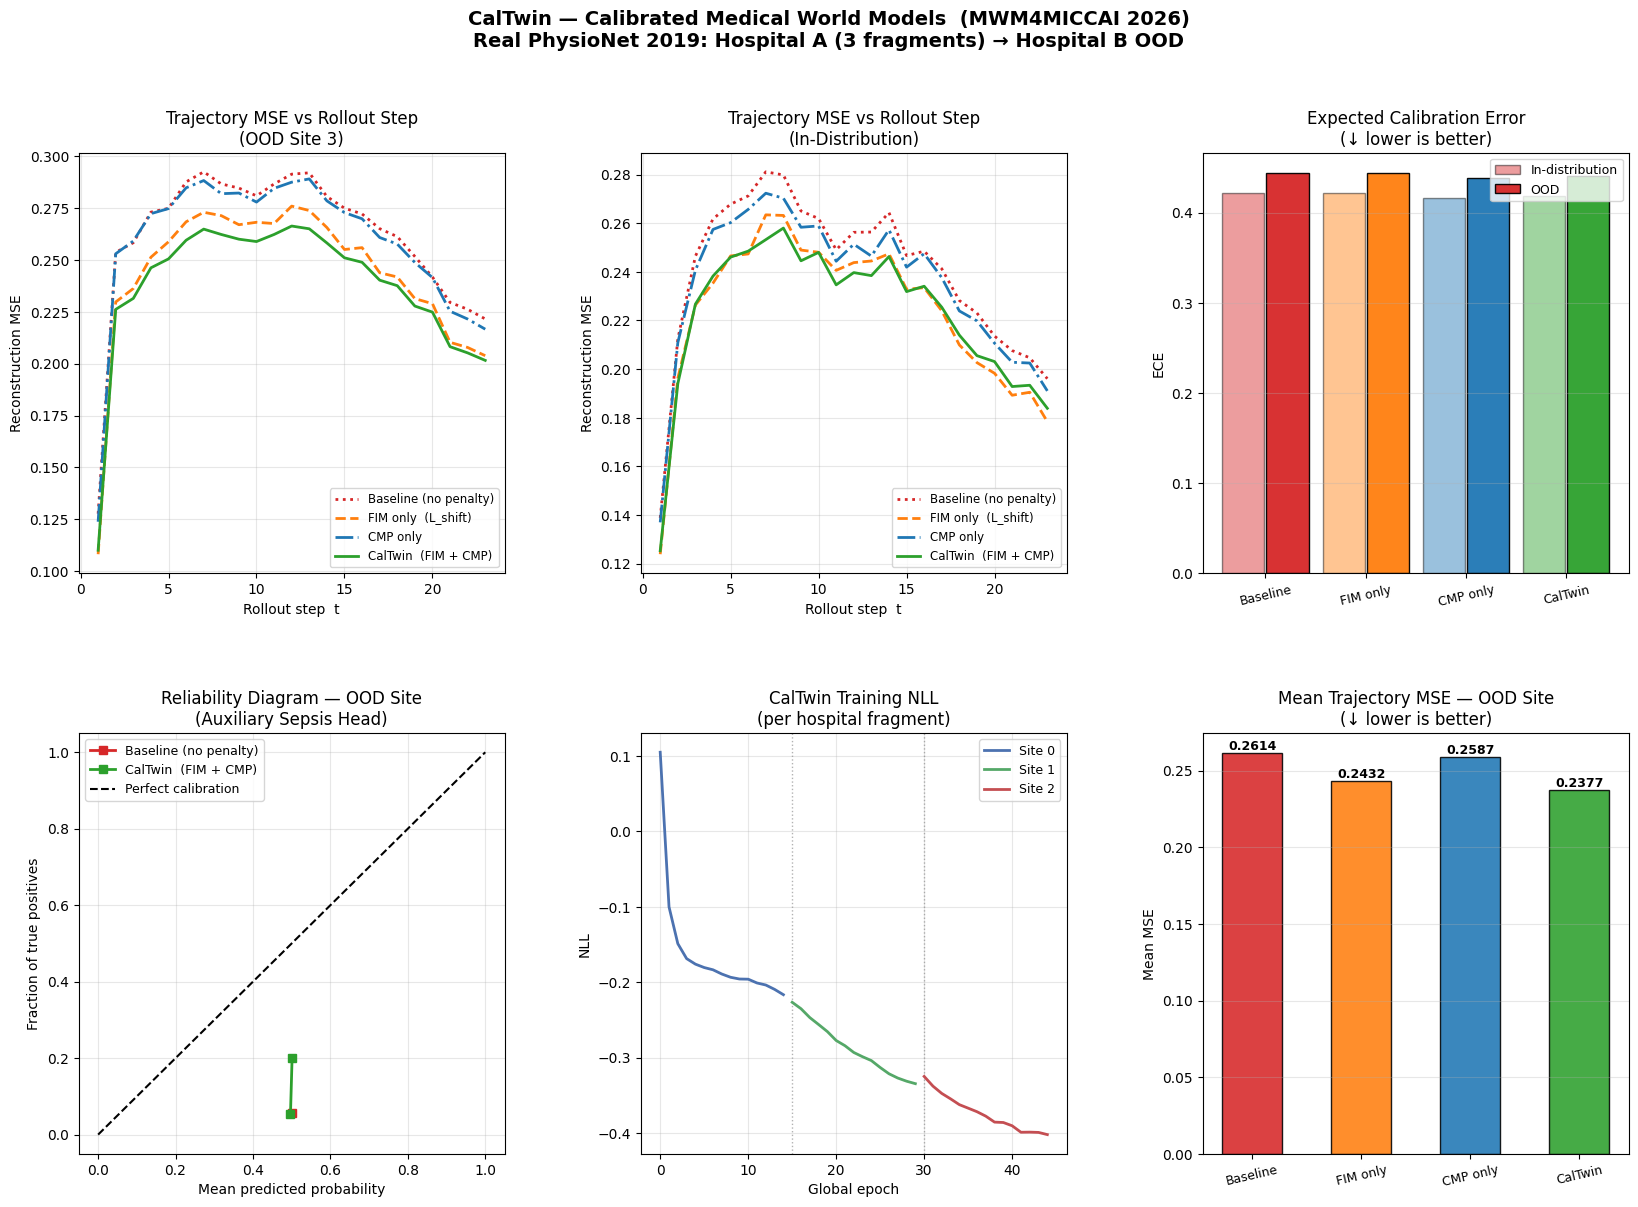


✅ Figure saved → caltwin_results.png


In [ ]:
fig = plt.figure(figsize=(20, 13))
_data_desc = ("Real PhysioNet 2019: Hospital A (3 fragments) → Hospital B OOD"
              if REAL_DATA_LOADED else
              "Synthetic multi-site ICU: 3 training fragments + 1 OOD test site")
fig.suptitle(
    "CalTwin — Calibrated Medical World Models  (MWM4MICCAI 2026)\n" + _data_desc,
    fontsize=14, fontweight="bold", y=0.99
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

steps = list(range(1, T_STEPS))

# ── Plot 1: MSE per step — OOD ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for m in METHODS:
    ax1.plot(steps, results[m]["ood"]["mse_curve"],
             label=LABELS[m], color=COLOURS[m], lw=2, ls=LINES[m])
ax1.set_title("Trajectory MSE vs Rollout Step\n(OOD Site 3)", fontsize=12)
ax1.set_xlabel("Rollout step  t"); ax1.set_ylabel("Reconstruction MSE")
ax1.legend(fontsize=8.5); ax1.grid(alpha=0.3)

# ── Plot 2: MSE per step — In-distribution ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for m in METHODS:
    ax2.plot(steps, results[m]["id"]["mse_curve"],
             label=LABELS[m], color=COLOURS[m], lw=2, ls=LINES[m])
ax2.set_title("Trajectory MSE vs Rollout Step\n(In-Distribution)", fontsize=12)
ax2.set_xlabel("Rollout step  t"); ax2.set_ylabel("Reconstruction MSE")
ax2.legend(fontsize=8.5); ax2.grid(alpha=0.3)

# ── Plot 3: ECE bar chart — ID vs OOD ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
xp = np.arange(len(METHODS))
ece_id  = [results[m]["id"]["ece"]  for m in METHODS]
ece_ood = [results[m]["ood"]["ece"] for m in METHODS]
ax3.bar(xp - 0.22, ece_id,  0.42, label="In-distribution",
        color=[COLOURS[m] for m in METHODS], alpha=0.45, edgecolor="k")
ax3.bar(xp + 0.22, ece_ood, 0.42, label="OOD",
        color=[COLOURS[m] for m in METHODS], alpha=0.95, edgecolor="k")
ax3.set_xticks(xp)
ax3.set_xticklabels([LABELS[m].split("(")[0].strip()
                     for m in METHODS], fontsize=9, rotation=13)
ax3.set_title("Expected Calibration Error\n(↓ lower is better)", fontsize=12)
ax3.set_ylabel("ECE")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3, axis="y")

# ── Plot 4: Reliability diagram — Baseline vs CalTwin (OOD) ──────────────
ax4 = fig.add_subplot(gs[1, 0])
for m in ["baseline", "caltwin"]:
    p = np.array(results[m]["ood"]["probs"])
    y = np.array(results[m]["ood"]["labels"])
    if len(np.unique(y)) > 1:
        fp, mp = calibration_curve(y, p, n_bins=10)
        ax4.plot(mp, fp, "s-", label=LABELS[m], color=COLOURS[m], lw=2)
ax4.plot([0,1],[0,1], "k--", lw=1.5, label="Perfect calibration")
ax4.set_title("Reliability Diagram — OOD Site\n(Auxiliary Sepsis Head)", fontsize=12)
ax4.set_xlabel("Mean predicted probability")
ax4.set_ylabel("Fraction of true positives")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── Plot 5: CalTwin training NLL per fragment ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
site_colors = ["#4c72b0", "#55a868", "#c44e52"]
for k in range(N_TRAIN_SITES):
    nll  = results["caltwin"]["history"][k]["nll"]
    offs = k * EPOCHS_PER_FRAG
    ax5.plot(range(offs, offs + len(nll)), nll,
             lw=2, color=site_colors[k], label=f"Site {k}")
    if k < N_TRAIN_SITES - 1:
        ax5.axvline(x=offs + EPOCHS_PER_FRAG,
                    color="grey", ls=":", alpha=0.6, lw=1)
ax5.set_title("CalTwin Training NLL\n(per hospital fragment)", fontsize=12)
ax5.set_xlabel("Global epoch"); ax5.set_ylabel("NLL")
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

# ── Plot 6: Mean OOD MSE bar chart ────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ood_mse = [results[m]["ood"]["mean_mse"] for m in METHODS]
bars = ax6.bar(xp, ood_mse, 0.55,
               color=[COLOURS[m] for m in METHODS],
               edgecolor="k", alpha=0.88)
ax6.set_xticks(xp)
ax6.set_xticklabels([LABELS[m].split("(")[0].strip()
                     for m in METHODS], fontsize=9, rotation=13)
ax6.set_title("Mean Trajectory MSE — OOD Site\n(↓ lower is better)", fontsize=12)
ax6.set_ylabel("Mean MSE")
for b, v in zip(bars, ood_mse):
    ax6.text(b.get_x() + b.get_width()/2, b.get_height() + 2e-4,
             f"{v:.4f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")
ax6.grid(alpha=0.3, axis="y")

plt.savefig("caltwin_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Figure saved → caltwin_results.png")